# Web Traffic

## Set Up

### Import Libraries

In [1]:
import warnings
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import zipfile

import pprint
from IPython.display import display
import datetime
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf , plot_accf_grid
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings

from scipy.interpolate import UnivariateSpline

from neuralforecast.models import LSTM
from neuralforecast.core import NeuralForecast
from neuralforecast.losses.pytorch import DistributionLoss, MAE, MSE, SMAPE
from sklearn.metrics import mean_squared_error, mean_absolute_error



### Import Data

In [2]:
#Load Dataset
path_to_zip = r'C:\Users\conno\ISyE6402Main\Time-Series-Analysis-Project\data\Web Traffic\train_2.csv.zip'
with zipfile.ZipFile(path_to_zip, 'r') as z:
    with z.open('train_2.csv') as f:
        data = pd.read_csv(f)

In [3]:
#Define function for dataset statistics
def get_dataset_stats(df):
    print(f"Sample Size: {len(df)}")
    print(f"Time Period: {df.index.min().date()} - {df.index.max().date()}")
    print(f"Missing Values: {df.isna().sum().sum()}")

In [4]:
#Create Dataframe for specific Film (Inside Out)
df = pd.DataFrame(data)
df.set_index('Page', inplace=True)
df = df.loc['Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents']
df.index = pd.to_datetime(df.index)

In [5]:
#Train off of first 180 days of the model. Test the following 14 days
train_end_range = round(180)
test_end_range = round(14)
df_train = pd.DataFrame({'Web_Traffic': df.iloc[0:train_end_range]})
df_test = pd.DataFrame({'Web_Traffic': df.iloc[train_end_range:(train_end_range+test_end_range)]})

In [6]:
# weekly_df = df.resample('W').sum()
# weekly_df_train = df_train.resample('W').sum()
# weekly_df_test = df_test.resample('W').sum()

### Examine Data Statistics

In [7]:
#Investigate Variable Data Types
df.info()

<class 'pandas.Series'>
DatetimeIndex: 803 entries, 2015-07-01 to 2017-09-10
Series name: Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents
Non-Null Count  Dtype  
--------------  -----  
802 non-null    float64
dtypes: float64(1)
memory usage: 12.5 KB


In [8]:
#Retrieve value statistics. It is evident from the statistics that there is a significant amount of variability in the dataset
df.describe()

count      802.000000
mean      9759.021197
std       9339.032000
min       2508.000000
25%       3879.000000
50%       5418.000000
75%      14000.500000
max      68182.000000
Name: Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents, dtype: float64

In [9]:
#Print dataset statistics
get_dataset_stats(df)

Sample Size: 803
Time Period: 2015-07-01 - 2017-09-10
Missing Values: 1


There is one missing value in the dataset. This value corresponds with the last date in the dataset: 2017-9-10. This will be addressed via imputation, however this datapoint was not utilized during the remaining analysis in this notebook.

In [10]:
df['2017-09-10'] = df['2017-09-09']

In [11]:
get_dataset_stats(df)

Sample Size: 803
Time Period: 2015-07-01 - 2017-09-10
Missing Values: 0


The missing value has been successfully imputed as the previous value in the dataset

## Data Exploration

### All Dates

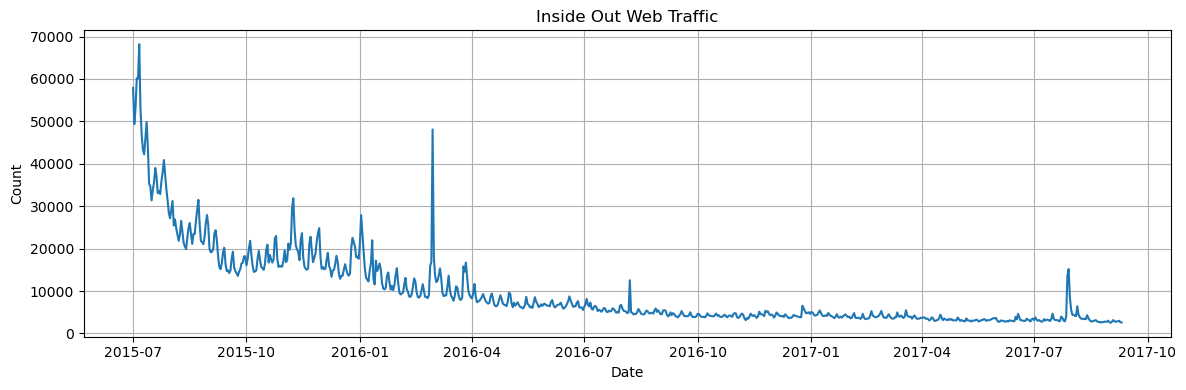

In [12]:
#Plot the data
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(df)
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlabel('Date')
plt.grid()

plt.tight_layout()
plt.show()

There is a very interesting pattern in this dataset. There is a clear downward trend as well as non-constant variance in the data. There are also 3 major instances of acute spikes in Web Traffic for the film Inside Out.

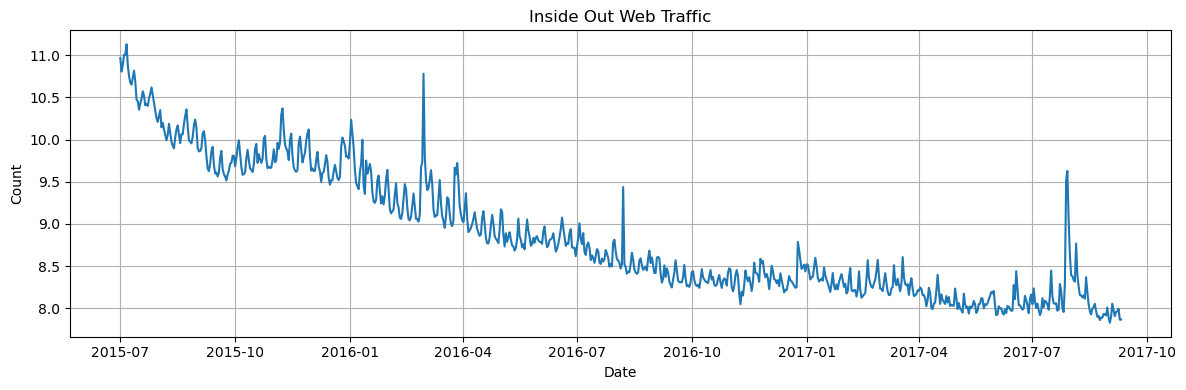

In [13]:
#Plot the log transformed data
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(np.log(df))
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlabel('Date')
plt.grid()

plt.tight_layout()
plt.show()

Log transforming the data significantly reduces the non-constant variance concern. The 3 major instances of acute spikes are still present in the plot.



In [14]:
#Transform the training and testing datasets
df_train_log = np.log(df_train)
df_test_log = np.log(df_test)

### Inside Out Web Traffic Analysis

#### ARIMA Model

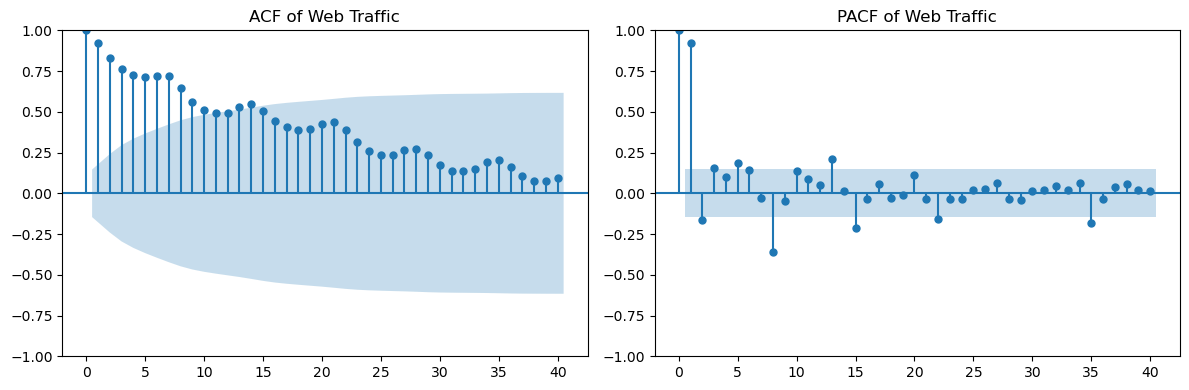

In [15]:
#Plot the ACF and PACF of the training dataset
fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train_log['Web_Traffic'], lags = 40, ax = ax1, title = 'ACF of Web Traffic')
plot_pacf(df_train_log['Web_Traffic'], lags = 40, ax = ax2, title = 'PACF of Web Traffic')

plt.tight_layout()
plt.show()

The ACF of the training dataset displays evidence of non-stationarity due ot its slow decay to zero. The confidence interval in the ACF plot is remarkably large. I believe this is due to the sample size of the training dataset.

The PACF plot displays a very strong direct correlation at the first lag of Web Traffic.

In [16]:
df_train_log_diff = df_train_log.diff()
df_train_log_diff.head()

,Web_Traffic
2015-07-01,NaN
2015-07-02,-0.158968
2015-07-03,0.076157
2015-07-04,0.121729
2015-07-05,-0.001630


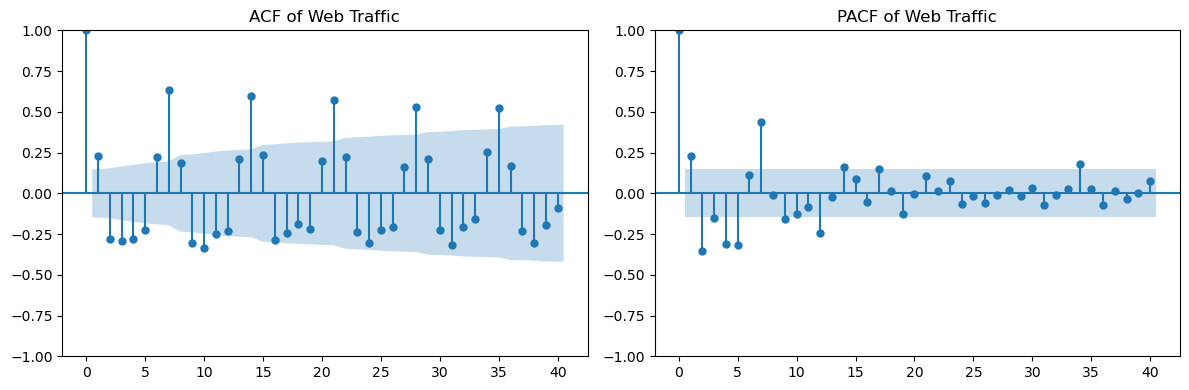

In [17]:
#Plot the ACF and PACF of the training dataset
fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train_log_diff[1:], lags = 40, ax = ax1, title = 'ACF of Web Traffic')
plot_pacf(df_train_log_diff[1:], lags = 40, ax = ax2, title = 'PACF of Web Traffic')

plt.tight_layout()
plt.show()

Plotting the differenced values of df_train_log help to identify max recommendations for testing for optimal AR and MA values in the future SARIMA model. Differencing the model also assists in making the dataset weakly stationary.

The PACF plot has significant autocorrelations up to lag 5, which recommends testing up to an AR lag of 5.

The ACF plot displays a clear 7 day seasonality, as well as an MA recommendation upo to lag 5.

In [18]:
#Fit an ARIMA model
max_ar=list(range(0,5+1))
max_ma=list(range(0,5+1))
max_sar = list(range(0,1+1))
max_sma = list(range(0,1+1))
shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))

aic_matrix = np.full(shape, np.inf)
aicc_matrix = np.full(shape, np.inf)
bic_matrix = np.full(shape, np.inf)

total = shape[0] * shape[1] * shape[2] * shape[3]
progress = tqdm(total=total, desc="ARIMA Grid Search")

for p in max_ar:
    for q in max_ma:
        for P in max_sar:
            for Q in max_sma:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        fit_result = SARIMAX(
                            df_train_log['Web_Traffic'],
                            order=(p, 1, q),
                            seasonal_order = (P,0,Q,7),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

                    k = len(fit_result.params)
                    n = len(df_train_log['Web_Traffic'])
                    aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)

                    aic_matrix[p, q, P, Q] = fit_result.aic
                    aicc_matrix[p, q, P, Q] = aicc
                    bic_matrix[p, q, P, Q] = fit_result.bic

                except Exception:

                    pass

                progress.update(1)

progress.close()
min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)

p_best = min_idx[0]
q_best = min_idx[1]
P_best = min_idx[2]
Q_best = min_idx[3]
best_value = aicc_matrix[min_idx]

print(p_best,
q_best,
P_best,
Q_best,
best_value)

ARIMA Grid Search: 100%|██████████| 144/144 [01:02<00:00,  2.30it/s]

4 4 0 0 -390.8832368197048


Interestingly, the optimal SARIMA values does not contain any seasonal component.

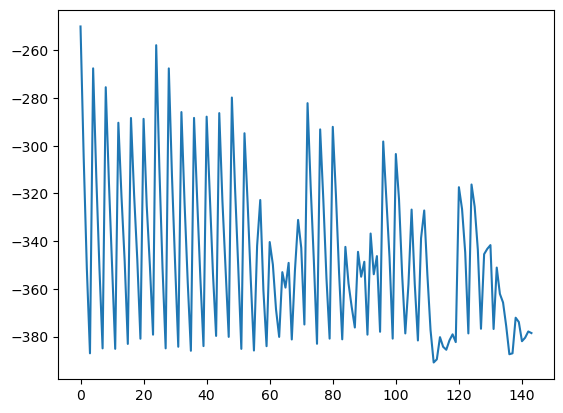

In [19]:
plt.plot(aicc_matrix.flatten())

In [20]:
#Fit the best performing SARIMA model that was identified.
sarima_model = SARIMAX(
                            df_train_log['Web_Traffic'],
                            order=(4, 1, 4),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train_log['SARIMA_resid'] = sarima_model.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


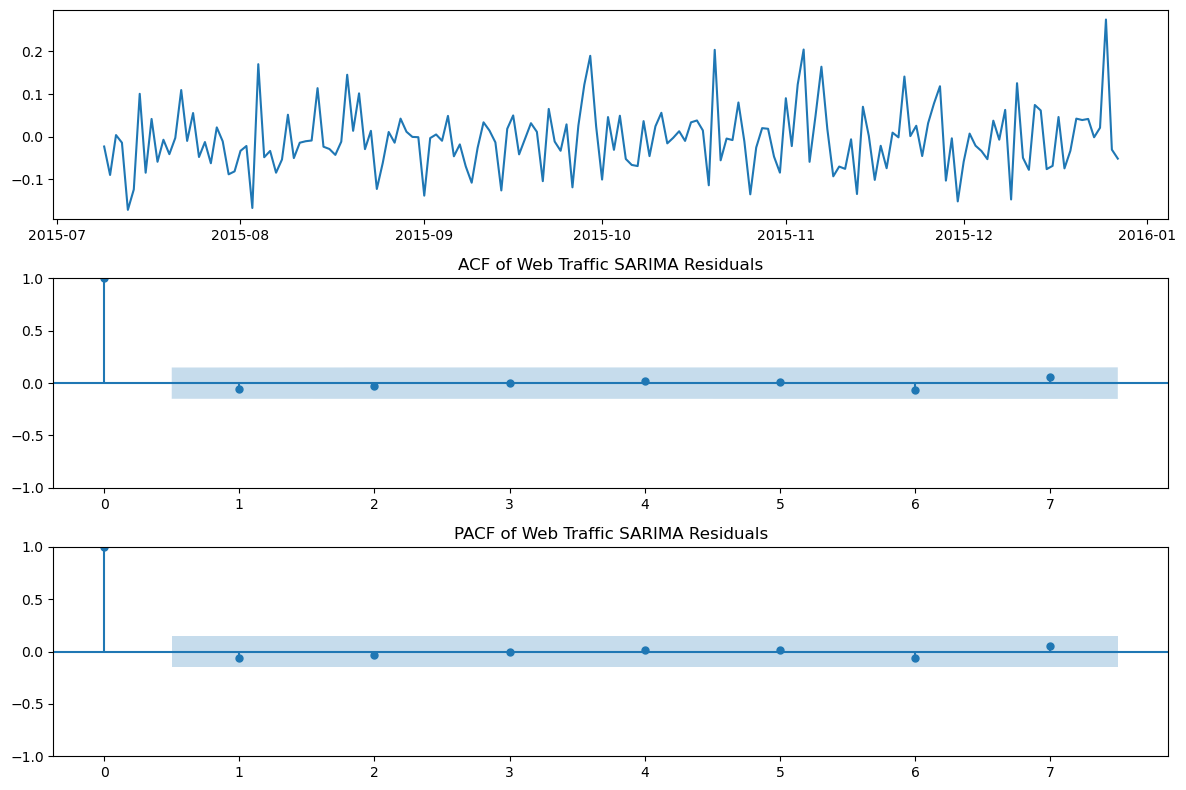

In [21]:
#Plot the data
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train_log['SARIMA_resid'].iloc[8:])
plot_acf(df_train_log['SARIMA_resid'].iloc[8:], lags = 7, ax = ax2, title = 'ACF of Web Traffic SARIMA Residuals')
plot_pacf(df_train_log['SARIMA_resid'].iloc[8:], lags = 7, ax = ax3, title = 'PACF of Web Traffic SARIMA Residuals')
plt.tight_layout()
plt.show()

The y-axis of the residuals displays that the residuals are very small, and largely display a white noise process. The plot of the residuals looks to satisfy all 3 conditions of weak stationarity.

The ACF and PACF plots display that all lagged autocorrelation has been removed from the model.

In [22]:
boxTest = acorr_ljungbox(df_train_log['SARIMA_resid'], lags=[7])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train_log['SARIMA_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train_log['SARIMA_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")

Ljung-Box: Test statistic = 0.2258; p-value = 1.0000
ADF: Test statistic = -144.2855; p-value = 0.0000
KPSS: Test statistic = 0.2865; p-value = 0.1000


The Ljung-Box test displays that there is no remaining significant autocorrelation in the model.
The ADF test's null hypothesis test is firmly rejected, so we conclude that the residuals are not non-stationary.
The KPSS test's null is not rejected, which draws the conclusion that the time series is stationary.

In [23]:
#Prepare predicitons for Web Traffic
pred_sarima_web_traffic_forecasts = sarima_model.get_forecast(steps=len(df_test_log['Web_Traffic']))
pred_sarima_web_traffic_confint = pred_sarima_web_traffic_forecasts.conf_int()
pred_sarima_web_traffic = pred_sarima_web_traffic_forecasts.predicted_mean

df_test_log['Web_Traffic'] = np.exp(df_test_log['Web_Traffic'])
df_test_log['Web_Traffic_SARIMA_pred'] = np.exp(pred_sarima_web_traffic)
df_test_log['Web_Traffic_SARIMA_lower_confint'] = np.exp(pred_sarima_web_traffic_confint['lower Web_Traffic'])
df_test_log['Web_Traffic_SARIMA_upper_confint'] = np.exp(pred_sarima_web_traffic_confint['upper Web_Traffic'])

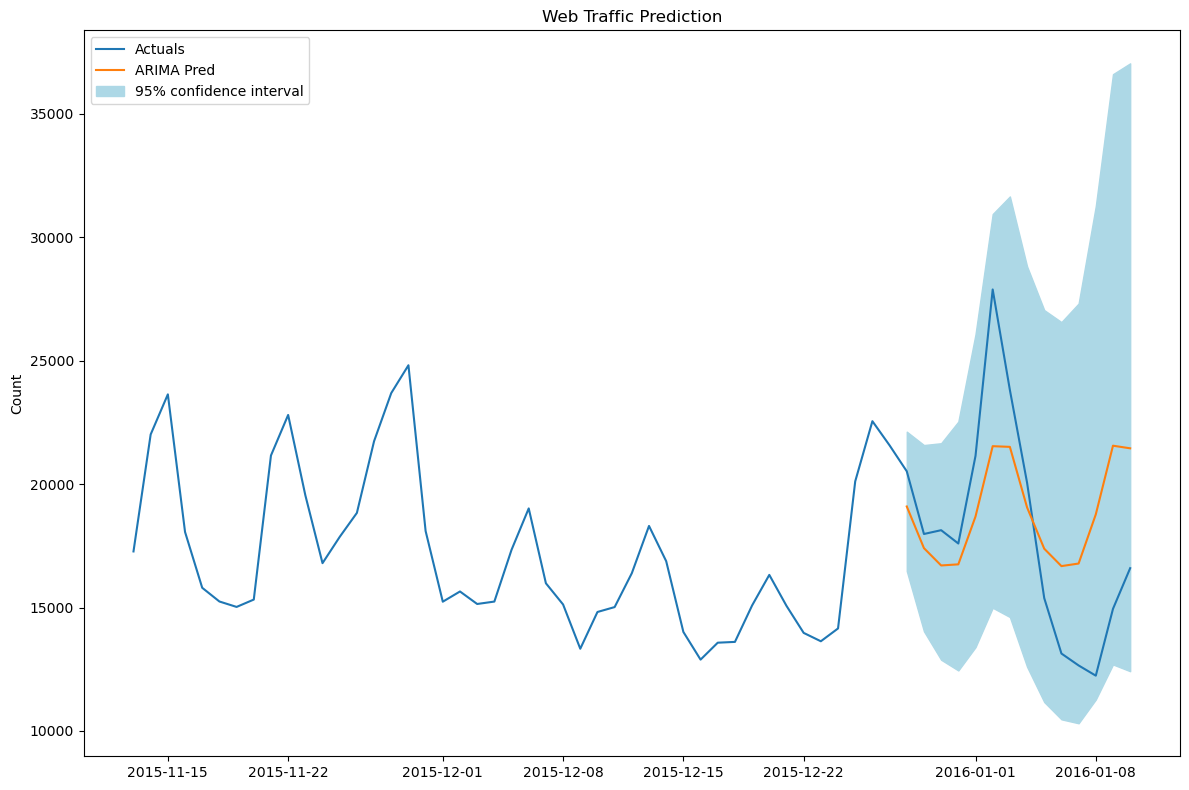

In [24]:
plt.figure(1,(12,8))
plt.plot(df.iloc[(len(df_train_log)-45):(len(df_train_log)+len(df_test_log))],label='Actuals')
plt.plot(df_test_log['Web_Traffic_SARIMA_pred'],label = 'ARIMA Pred')
plt.fill_between(df_test_log.index, df_test_log['Web_Traffic_SARIMA_lower_confint'], df_test_log['Web_Traffic_SARIMA_upper_confint'], label = "95% confidence interval", color = 'lightblue')
plt.title('Web Traffic Prediction')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
#Calculate Precision Measure
df_test_log['Web_Traffic_SARIMA_resid'] = df_test_log['Web_Traffic_SARIMA_pred'] - df_test_log['Web_Traffic']
final_sarima_pred_pm = np.sum(df_test_log['Web_Traffic_SARIMA_resid']**2)/np.sum((df_test_log['Web_Traffic']-np.mean(df_test_log['Web_Traffic']))**2)
print(final_sarima_pred_pm)

0.7871914200061095


The precision measure calculated at 0.78, which means that the prediction error is less than the variance of the test dataset. This is generally a positive indicator that the model has useful predictive performance.

### LSTM Model

In [26]:
# Function to be utilized during the iterative process to identify a well performing LSTM model
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

In [27]:
# Reformat data to be utilized with LSTM function. Log transforming df_train_log_lstm for an apples to apples comparison with the SARIMA model
df_lstm = pd.DataFrame({'y':np.log(df)}).copy()
df_lstm.reset_index(inplace=True)
df_lstm.rename(columns={'index':'ds'},inplace=True)
df_lstm['unique_id'] = 'ts1'
df_lstm = df_lstm[['ds','y','unique_id']]

df_train_lstm = df_lstm.iloc[:train_end_range]
df_test_lstm = df_lstm.iloc[train_end_range:(train_end_range+test_end_range)]


In [28]:
# Identify the proper input_size
horizon = 14
input_sizes = [-1, 2, 3, 5, 10, 30, 45]

for input_size in input_sizes:
    print(f"\nTraining LSTM with input_size = {input_size}")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=input_size,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type='robust',
        encoder_n_layers=1,
        encoder_hidden_size=4,
        decoder_hidden_size=4,
        decoder_layers=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        max_steps=200,
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    evaluate_performance(y_true, y_pred, model_name=f"LSTM (input_size={input_size})")

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\neuralforecast\common\_base_model.py:152: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
  warnings.warn(
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with input_size = -1


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=-1) Performance ===
MSPE: 0.0853
MAE:  0.2384
MAPE: 0.0241
PM:   1.5844
----------------------------------------

Training LSTM with input_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

=== LSTM (input_size=10) Performance ===
MSPE: 0.0857
MAE:  0.2405
MAPE: 0.0243
PM:   1.5929
----------------------------------------

Training LSTM with input_size = 30


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=30) Performance ===
MSPE: 0.0897
MAE:  0.2440
MAPE: 0.0246
PM:   1.6674
----------------------------------------

Training LSTM with input_size = 45


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=45) Performance ===
MSPE: 0.0752
MAE:  0.2243
MAPE: 0.0227
PM:   1.3976
----------------------------------------


The input size of 5 has the best performance metrics, given the rest of the starting parameters.

In [29]:
# Identify the scaler types
horizon = 14
scaler_types = ['identity', 'standard', 'robust']

for scaler in scaler_types:
    print(f"\nTraining LSTM with scaler_type = '{scaler}'")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=5,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type=scaler,
        encoder_n_layers=1,
        encoder_hidden_size=4,
        decoder_hidden_size=4,
        decoder_layers=1,
        max_steps=200,
        enable_progress_bar=False,
        enable_model_summary=False,
        # trainer=trainer
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    # Evaluate
    evaluate_performance(y_true, y_pred, model_name=f"LSTM (scaler_type='{scaler}')")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with scaler_type = 'identity'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='identity') Performance ===
MSPE: 84.6267
MAE:  9.1882
MAPE: 0.9404
PM:   1572.6188
----------------------------------------

Training LSTM with scaler_type = 'standard'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='standard') Performance ===
MSPE: 0.0612
MAE:  0.2072
MAPE: 0.0211
PM:   1.1364
----------------------------------------

Training LSTM with scaler_type = 'robust'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='robust') Performance ===
MSPE: 0.0700
MAE:  0.2161
MAPE: 0.0224
PM:   1.3006
----------------------------------------


The "Standard" scaler type has the best performance metrics, given the rest of the parameters.

In [30]:
# Identify the best performing structure_combination
horizon = 14
input_size = 5
scaler_type = 'standard'

structure_combinations = [
    (1, 2),
    (1, 4),
    (1, 8),
    (1, 16),
    (2, 2),
    (2, 4)
]

for n_layers, hidden_size in structure_combinations:
    print(f"\nTraining LSTM with encoder_n_layers = {n_layers}, encoder_hidden_size = {hidden_size}")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=input_size,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type=scaler_type,
        encoder_n_layers=n_layers,
        encoder_hidden_size=hidden_size,
        decoder_hidden_size=hidden_size,
        decoder_layers=1,
        max_steps=200,
        enable_progress_bar=False,
        enable_model_summary=False
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    # Evaluate
    evaluate_performance(y_true, y_pred, model_name=f"LSTM (layers={n_layers}, hidden={hidden_size})")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with encoder_n_layers = 1, encoder_hidden_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=1, hidden=2) Performance ===
MSPE: 0.0538
MAE:  0.2009
MAPE: 0.0205
PM:   1.0000
----------------------------------------

Training LSTM with encoder_n_layers = 1, encoder_hidden_size = 4


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

=== LSTM (layers=1, hidden=16) Performance ===
MSPE: 0.0615
MAE:  0.2095
MAPE: 0.0213
PM:   1.1433
----------------------------------------

Training LSTM with encoder_n_layers = 2, encoder_hidden_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=2, hidden=2) Performance ===
MSPE: 0.0652
MAE:  0.2207
MAPE: 0.0224
PM:   1.2123
----------------------------------------

Training LSTM with encoder_n_layers = 2, encoder_hidden_size = 4


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=2, hidden=4) Performance ===
MSPE: 0.0670
MAE:  0.2166
MAPE: 0.0220
PM:   1.2455
----------------------------------------


The best performing option is: layers = 1, hidden = 2, given the rest of the parameters.

In [31]:
#Identify best loss candidate
loss_candidates = [
    ("Normal", DistributionLoss(distribution='Normal', level=[90, 95])),
    ("MAE", MAE()),
    ("MSE", MSE()),
    ("SMAPE", SMAPE()),
]

results = []

for loss_name, loss_obj in loss_candidates:
    alias = f"LSTM_{loss_name}"
    print(f"\n=== Training {alias} ===")
    lstm_model = LSTM(
        h=14,
        input_size=5,
        loss=loss_obj,
        scaler_type='standard',
        encoder_hidden_size=2,
        decoder_hidden_size=2,
        encoder_n_layers=1,
        decoder_layers=1,
        max_steps=200,
        alias=alias,
        enable_progress_bar=False,
        enable_model_summary=False
    )

    # Fit & Predict
    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    forecasts = nf.predict()

    merged = forecasts.merge(df_test_lstm[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')


    y_true = merged['y'].values
    y_pred = merged[alias].values


    evaluate_performance(y_true, y_pred, model_name=f"{alias}")


Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



=== Training LSTM_Normal ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_Normal Performance ===
MSPE: 0.0538
MAE:  0.2009
MAPE: 0.0205
PM:   1.0000
----------------------------------------

=== Training LSTM_MAE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_MAE Performance ===
MSPE: 0.0615
MAE:  0.1954
MAPE: 0.0199
PM:   1.1430
----------------------------------------

=== Training LSTM_MSE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_MSE Performance ===
MSPE: 0.0524
MAE:  0.1782
MAPE: 0.0182
PM:   0.9735
----------------------------------------

=== Training LSTM_SMAPE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_SMAPE Performance ===
MSPE: 0.0928
MAE:  0.2540
MAPE: 0.0263
PM:   1.7245
----------------------------------------


The best loss candidate is MSE, given the rest of the chosen parameters.

In [32]:
#Create the final LSTM model
horizon = 14
lstm_model = LSTM(
    h=horizon,
    input_size=5,
    #context_size=30,
    loss=MSE(),
    #loss=MAE(),
    scaler_type='standard',
    encoder_n_layers=1,
    encoder_hidden_size=2,
    decoder_hidden_size=2,
    decoder_layers=1,
    max_steps=200,
    enable_progress_bar=False,
    enable_model_summary=False
)

nf = NeuralForecast(models=[lstm_model],freq='D')
nf.fit(df=df_train_lstm)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=200` reached.


In [34]:
# Predict
forecasts = nf.predict()

#Remove log transform
forecasts['LSTM'] = np.exp(forecasts['LSTM'])
df_test_lstm['y'] = np.exp(df_test_lstm['y'])
df_train_lstm['y'] = np.exp(df_train_lstm['y'])


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


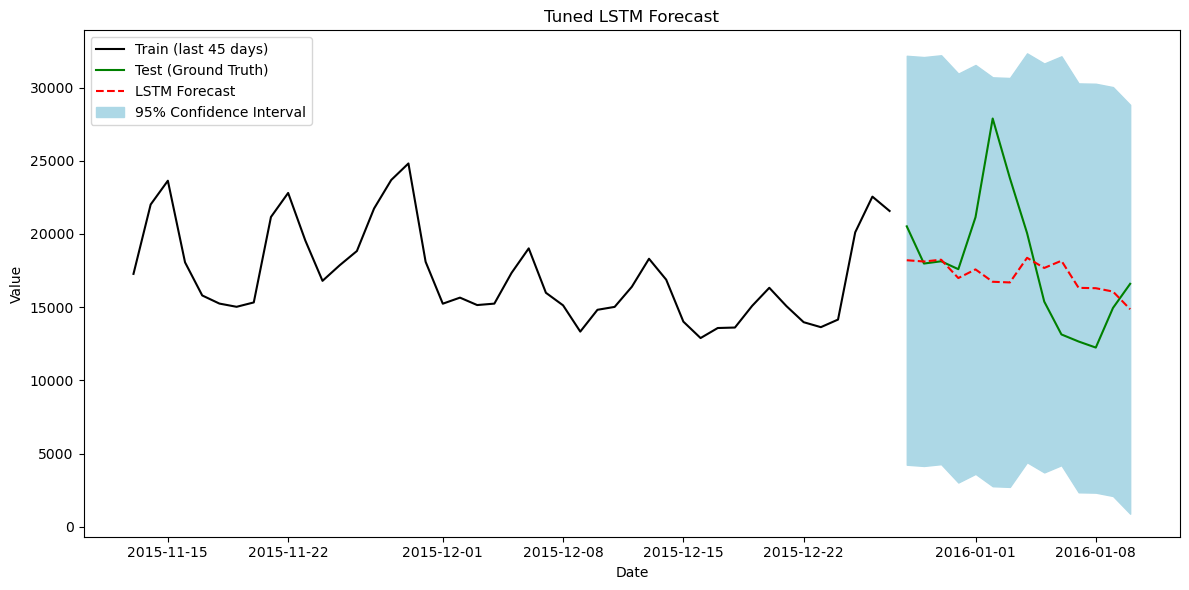

In [35]:
# Merge forecast with test set for comparison
merged = forecasts.merge(df_test_lstm, on='ds', how='inner')
plt.figure(figsize=(12, 6))

# Get the start date of the test set
test_start_date = df_test_lstm['ds'].min()
# Select last 45 days from train_data before test starts
train_subset = df_train_lstm[df_train_lstm['ds'] >= test_start_date - pd.Timedelta(days=45)]
# Plot training data
plt.plot(train_subset['ds'], train_subset['y'], label='Train (last 45 days)', color='black')

#Calculate the rmse for prediction interval estimation
train_preds = nf.predict_insample().dropna()
rmse = np.sqrt(mean_squared_error(np.exp(train_preds['y']), np.exp(train_preds['LSTM'])))

upper_pred_interval = merged['LSTM'] + (1.96*rmse)
lower_pred_interval = merged['LSTM'] - (1.96*rmse)

# Plot test data (ground truth)
plt.plot(merged['ds'], merged['y'], label='Test (Ground Truth)', color='green')
plt.plot(merged['ds'], merged['LSTM'], label='LSTM Forecast', color='red', linestyle='--')

#Plot the estimated 95% prediction interval
plt.fill_between(merged['ds'], lower_pred_interval, upper_pred_interval, color='lightblue', label='95% Confidence Interval')


# Final plot adjustments
plt.title('Tuned LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

The LSTM prediction seems to estimate the mean of the test dataset well, howeve it does not capture the variability of the test datapoints. All test datapoints are within the estimated prediction intervals (RMSE).

In [36]:
merged['LSTM residuals'] = merged['y']-merged['LSTM']
final_lstm_pred_pm = np.sum(merged['LSTM residuals']**2)/np.sum((merged['y']-np.mean(merged['y']))**2)

In [37]:
print(f'SARIMA PM: {final_sarima_pred_pm}')
print(f'LSTM PM: {final_lstm_pred_pm}')

SARIMA PM: 0.7871914200061095
LSTM PM: 1.0213149167068838


Judging by the performance measure, the SARIMA model performed much better at forecasting the test dataset's values.

LSTM, due to its natue of being a deep learning model, typically benefits greatly from being trained on a large dataset. This dataset is small, and was utilized to compare and contrast the performance of LSTMo n a smaller dataset to that of SARIMA.